In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU - HARUS GANTI KE GPU!")

GPU available: True
Device: Tesla T4


In [ ]:
import os
os.environ['WANDB_DISABLED'] = 'true'
os.environ['WANDB_MODE'] = 'disabled'

!pip install wandb -q
import wandb
wandb.init(mode="disabled")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


In [ ]:
import os
os.environ['WANDB_DISABLED'] = 'true'
os.environ['WANDB_MODE'] = 'disabled'

!pip install ultralytics roboflow grad-cam -q

import ultralytics
ultralytics.checks()

import torch
print("GPU:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "MASIH CPU!")

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)
GPU: True
Device: Tesla T4


In [ ]:
import os
os.environ['WANDB_DISABLED'] = 'true'

from roboflow import Roboflow

rf = Roboflow(api_key="vnG3wVcnKUECpJo9pYge")
project = rf.workspace("ghanis-workspace-cjm94").project("coba-projek-uas")
version = project.version(1)
dataset = version.download("yolov8")

print("Dataset path:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to coba-projek-uas-1 in yolov8:: 100%|██████████| 15004/15004 [00:02<00:00, 6422.55it/s] 


Dataset path: /content/coba-projek-uas-1


In [ ]:
import yaml, os

yaml_path = os.path.join(dataset.location, "data.yaml")

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['names'] = ['Kosong', 'Terisi', 'Penuh']
data['nc'] = 3

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

with open(yaml_path, 'r') as f:
    print(f.read())

names:
- Kosong
- Terisi
- Penuh
nc: 3
roboflow:
  license: CC BY 4.0
  project: coba-projek-uas
  url: https://universe.roboflow.com/ghanis-workspace-cjm94/coba-projek-uas/dataset/1
  version: 1
  workspace: ghanis-workspace-cjm94
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
import os
from pathlib import Path
from sklearn.model_selection import KFold
import shutil, yaml

train_img_dir = os.path.join(dataset.location, 'train', 'images')
train_lbl_dir = os.path.join(dataset.location, 'train', 'labels')

all_images = sorted(
    list(Path(train_img_dir).glob('*.jpg')) +
    list(Path(train_img_dir).glob('*.png'))
)

print(f"Total training images: {len(all_images)}")

K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)
folds = list(kf.split(all_images))

kfold_base = "/content/kfold_dataset"
os.makedirs(kfold_base, exist_ok=True)

for fold_idx, (train_idx, val_idx) in enumerate(folds):
    fold_dir = os.path.join(kfold_base, f"fold_{fold_idx+1}")

    for split in ['train', 'val']:
        os.makedirs(os.path.join(fold_dir, split, 'images'), exist_ok=True)
        os.makedirs(os.path.join(fold_dir, split, 'labels'), exist_ok=True)

    for idx in train_idx:
        img_file = all_images[idx]
        lbl_file = Path(train_lbl_dir) / (img_file.stem + '.txt')
        shutil.copy(img_file, os.path.join(fold_dir, 'train', 'images', img_file.name))
        if lbl_file.exists():
            shutil.copy(lbl_file, os.path.join(fold_dir, 'train', 'labels', lbl_file.name))

    for idx in val_idx:
        img_file = all_images[idx]
        lbl_file = Path(train_lbl_dir) / (img_file.stem + '.txt')
        shutil.copy(img_file, os.path.join(fold_dir, 'val', 'images', img_file.name))
        if lbl_file.exists():
            shutil.copy(lbl_file, os.path.join(fold_dir, 'val', 'labels', lbl_file.name))

    fold_yaml = {
        'train': os.path.join(fold_dir, 'train', 'images'),
        'val':   os.path.join(fold_dir, 'val', 'images'),
        'nc': 3,
        'names': ['Kosong', 'Terisi', 'Penuh']
    }
    with open(os.path.join(fold_dir, 'data.yaml'), 'w') as f:
        yaml.dump(fold_yaml, f)

    print(f"Fold {fold_idx+1}: train={len(train_idx)}, val={len(val_idx)}")

Total training images: 6000
Fold 1: train=4800, val=1200
Fold 2: train=4800, val=1200
Fold 3: train=4800, val=1200
Fold 4: train=4800, val=1200
Fold 5: train=4800, val=1200


In [ ]:
import os
os.environ['WANDB_DISABLED'] = 'true'
os.environ['WANDB_MODE'] = 'disabled'

from ultralytics import YOLO

K = 5
kfold_base = "/content/kfold_dataset"
results_per_fold = []

for fold_idx in range(K):
    print(f"\n{'='*60}")
    print(f"TRAINING FOLD {fold_idx+1} / {K}")
    print(f"{'='*60}")

    fold_yaml = os.path.join(kfold_base, f"fold_{fold_idx+1}", "data.yaml")

    model = YOLO("yolo11s.pt")

    results = model.train(
        data=fold_yaml,
        epochs=10,
        imgsz=640,
        batch=16,
        optimizer='AdamW',
        lr0=0.001667,
        momentum=0.9,
        patience=3,
        augment=True,
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        fliplr=0.5,
        mosaic=1.0,
        mixup=0.1,
        device=0,
        project='/content/runs/kfold',
        name=f'fold_{fold_idx+1}',
        verbose=True,
        save=True,
        plots=True
    )

    fold_result = {
        'fold':      fold_idx + 1,
        'mAP50':     results.results_dict.get('metrics/mAP50(B)', 0),
        'mAP50_95':  results.results_dict.get('metrics/mAP50-95(B)', 0),
        'precision': results.results_dict.get('metrics/precision(B)', 0),
        'recall':    results.results_dict.get('metrics/recall(B)', 0),
    }
    results_per_fold.append(fold_result)

    print(f"Fold {fold_idx+1} → mAP@0.5={fold_result['mAP50']:.4f} | "
          f"mAP@0.5:0.95={fold_result['mAP50_95']:.4f} | "
          f"P={fold_result['precision']:.4f} | "
          f"R={fold_result['recall']:.4f}")


TRAINING FOLD 1 / 5
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kfold_dataset/fold_1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001667, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11s.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, name=fold_1-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW,

In [ ]:
import pandas as pd
import numpy as np

df = pd.DataFrame(results_per_fold)
print(df.to_string(index=False))

print("\nRATA-RATA ± STD")
for col in ['mAP50', 'mAP50_95', 'precision', 'recall']:
    print(f"  {col:15s}: {df[col].mean():.4f} ± {df[col].std():.4f}")

df.to_csv('/content/kfold_results.csv', index=False)

 fold    mAP50  mAP50_95  precision   recall
    1 0.991682  0.983313   0.962053 0.966253
    2 0.992207  0.980731   0.969353 0.974373
    3 0.988103  0.961614   0.967485 0.961948
    4 0.987424  0.976446   0.964676 0.950179
    5 0.992186  0.965584   0.965402 0.963061

RATA-RATA ± STD
  mAP50          : 0.9903 ± 0.0024
  mAP50_95       : 0.9735 ± 0.0095
  precision      : 0.9658 ± 0.0028
  recall         : 0.9632 ± 0.0087


In [ ]:
best_fold = max(results_per_fold, key=lambda x: x['mAP50'])
print(f"Best fold : {best_fold['fold']}")
print(f"mAP@0.5   : {best_fold['mAP50']:.4f}")
print(f"mAP@0.5:95: {best_fold['mAP50_95']:.4f}")
print(f"Precision : {best_fold['precision']:.4f}")
print(f"Recall    : {best_fold['recall']:.4f}")

best_weight = f"/content/runs/kfold/fold_{best_fold['fold']}/weights/best.pt"
print(f"\nBest weight: {best_weight}")

Best fold : 2
mAP@0.5   : 0.9922
mAP@0.5:95: 0.9807
Precision : 0.9694
Recall    : 0.9744

Best weight: /content/runs/kfold/fold_2/weights/best.pt


coba lime

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=bce9e028b5cc70c72e0e4d69bfe537db4d2f6102b26f0bf4b25a274dd14b1300
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from lime import lime_image
from skimage.segmentation import mark_boundaries

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/kfold/fold_2-2/weights/best.pt")

In [ ]:
import random
image_path = random.choice(images)

print(image_path)

/content/coba-projek-uas-1/valid/images/Terisi_2471_jpg.rf.f72e669e2261c05e5c824acb1a81ae2c.jpg


In [ ]:
import cv2

def predict_fn(images):
    outputs = []

    for img in images:

        img_uint8 = (img * 255).astype(np.uint8)

        results = model.predict(
            source=img_uint8,
            verbose=False
        )

        probs = np.zeros(len(model.names))

        if len(results[0].boxes) > 0:

            for box in results[0].boxes:

                cls = int(box.cls.cpu().numpy())
                conf = float(box.conf.cpu().numpy())

                probs[cls] = max(probs[cls], conf)

        outputs.append(probs)

    return np.array(outputs)

In [ ]:
img = Image.open(image_path).convert("RGB")
img = img.resize((640,640))

img_np = np.array(img)

In [ ]:
explainer = lime_image.LimeImageExplainer()

In [ ]:
explanation = explainer.explain_instance(
    img_np,
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

  0%|          | 0/1000 [00:00<?, ?it/s]

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)


In [ ]:
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=10,
    hide_rest=False
)

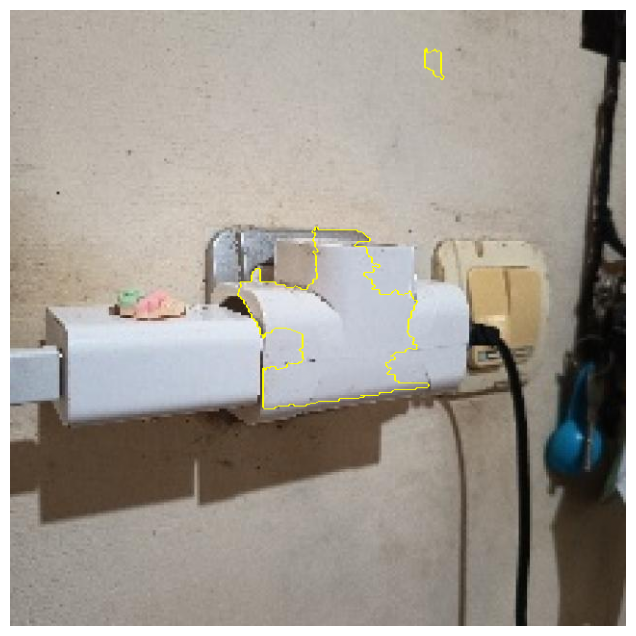

In [ ]:
plt.figure(figsize=(8,8))

plt.imshow(mark_boundaries(temp / 255.0, mask))

plt.axis("off")

plt.show()